In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import MultinomialNB

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ML/datasets/tripadvisor_hotel_reviews.csv")
df

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5
...,...,...
20486,"best kept secret 3rd time staying charm, not 5...",5
20487,great location price view hotel great quick pl...,4
20488,"ok just looks nice modern outside, desk staff ...",2
20489,hotel theft ruined vacation hotel opened sept ...,1


In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.shape

(20491, 2)

In [ ]:
df.isnull().sum()

,0
Review,0
Rating,0


In [ ]:
def sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df["Sentiment"] = df["Rating"].apply(sentiment)

In [ ]:
print(df.columns)

Index(['Review', 'Rating'], dtype='object')


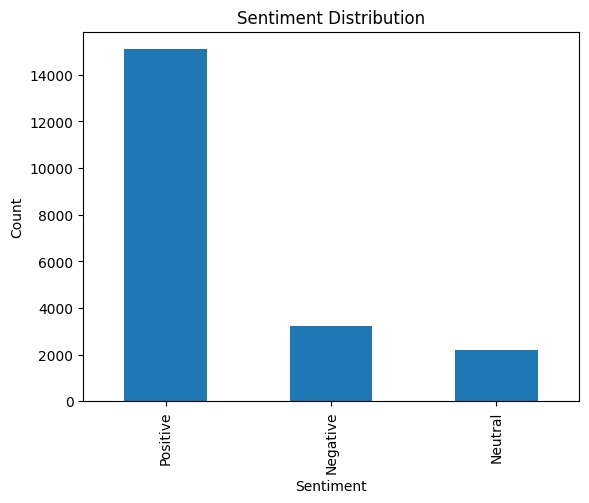

In [ ]:
import matplotlib.pyplot as plt

df["Sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

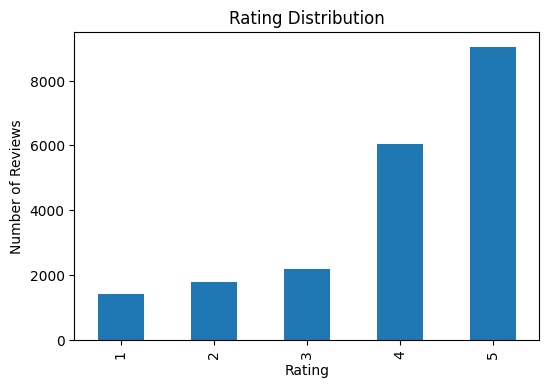

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

df["Rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

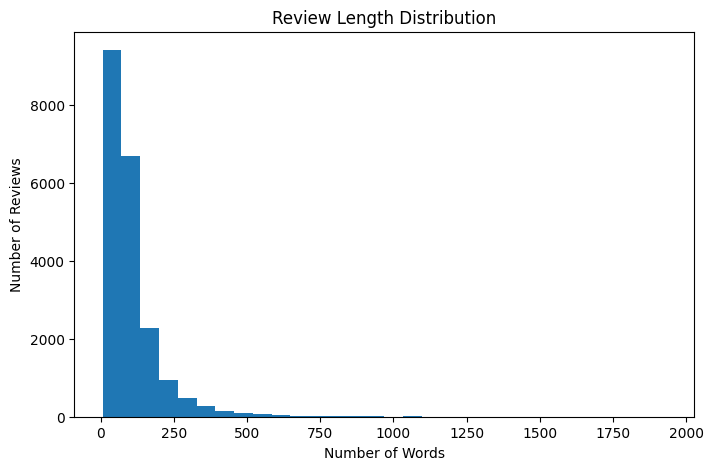

In [ ]:
# Review length (number of words)
df["Review_Length"] = df["Review"].apply(lambda x: len(str(x).split()))

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["Review_Length"], bins=30)

plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

plt.show()

In [ ]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+","",text)

    text = re.sub(r"\d+","",text)

    text = text.translate(str.maketrans("","",string.punctuation))

    text = re.sub(r"\s+"," ",text)

    return text

df["Clean_Review"] = df["Review"].apply(clean_text)

In [ ]:
tfidf = TfidfVectorizer(stop_words='english')

X = tfidf.fit_transform(df["Clean_Review"])

y = df["Sentiment"]

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
lr = LogisticRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_lr))

print(classification_report(y_test,pred_lr))

Accuracy: 0.856306416199073
              precision    recall  f1-score   support

    Negative       0.80      0.73      0.77       625
     Neutral       0.53      0.17      0.26       432
    Positive       0.88      0.98      0.93      3042

    accuracy                           0.86      4099
   macro avg       0.74      0.63      0.65      4099
weighted avg       0.83      0.86      0.83      4099



In [ ]:
nb = MultinomialNB()

nb.fit(X_train,y_train)

pred_nb = nb.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_nb))

print(classification_report(y_test,pred_nb))

Accuracy: 0.742620151256404
              precision    recall  f1-score   support

    Negative       1.00      0.00      0.01       625
     Neutral       0.00      0.00      0.00       432
    Positive       0.74      1.00      0.85      3042

    accuracy                           0.74      4099
   macro avg       0.58      0.33      0.29      4099
weighted avg       0.70      0.74      0.63      4099



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
dt = DecisionTreeClassifier()

dt.fit(X_train,y_train)

pred_dt = dt.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_dt))

print(classification_report(y_test,pred_dt))

Accuracy: 0.7404244937789705
              precision    recall  f1-score   support

    Negative       0.54      0.55      0.54       625
     Neutral       0.21      0.18      0.19       432
    Positive       0.85      0.86      0.85      3042

    accuracy                           0.74      4099
   macro avg       0.53      0.53      0.53      4099
weighted avg       0.73      0.74      0.74      4099



In [ ]:
rf = RandomForestClassifier()

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_rf))

print(classification_report(y_test,pred_rf))

Accuracy: 0.7850695291534521
              precision    recall  f1-score   support

    Negative       0.95      0.28      0.44       625
     Neutral       0.00      0.00      0.00       432
    Positive       0.78      1.00      0.87      3042

    accuracy                           0.79      4099
   macro avg       0.57      0.43      0.44      4099
weighted avg       0.72      0.79      0.72      4099



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
results = pd.DataFrame({

"Model":[
"Logistic Regression",
"Naive Bayes",
"Decision Tree",
"Random Forest"
],

"Accuracy":[

accuracy_score(y_test,pred_lr),

accuracy_score(y_test,pred_nb),

accuracy_score(y_test,pred_dt),

accuracy_score(y_test,pred_rf)

]

})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.856306
1          Naive Bayes  0.742620
2        Decision Tree  0.740424
3        Random Forest  0.785070


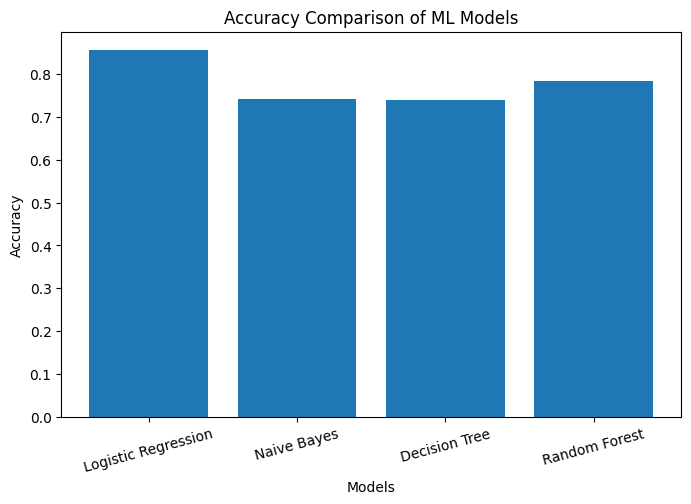

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Accuracy Comparison of ML Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=15)

plt.show()

In [ ]:
review = ["The hotel was excellent and staff were friendly"]

review = [clean_text(i) for i in review]

review = tfidf.transform(review)

prediction = lr.predict(review)

print(prediction)

['Positive']


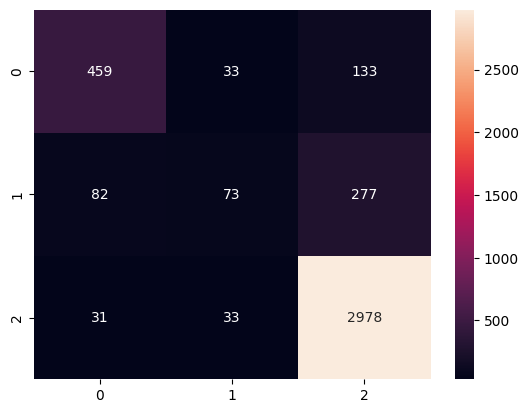

In [ ]:
cm = confusion_matrix(y_test,pred_lr)

sns.heatmap(cm,annot=True,fmt='d')

plt.show()

In [ ]:
import pickle

# Save Logistic Regression model
with open("sentiment_model.pkl", "wb") as f:
    pickle.dump(lr, f)

# Save TF-IDF Vectorizer
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print(" Model and Vectorizer saved successfully!")

 Model and Vectorizer saved successfully!
